--2026-01-29 22:36:21--  https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/matomo-org/travis-scripts/master/fonts/Arial.ttf [following]
--2026-01-29 22:36:26--  https://raw.githubusercontent.com/matomo-org/travis-scripts/master/fonts/Arial.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 275572 (269K) [application/octet-stream]
Saving to: ‘/usr/share/fonts/truetype/arial/Arial.ttf’

/usr/share/fonts/tr 100%[===================>] 269.11K  --.-KB/s    in 0.003s  

2026-01-29 22:36:26 (91.7 MB/s) - ‘/usr/share/fonts/truetype/a

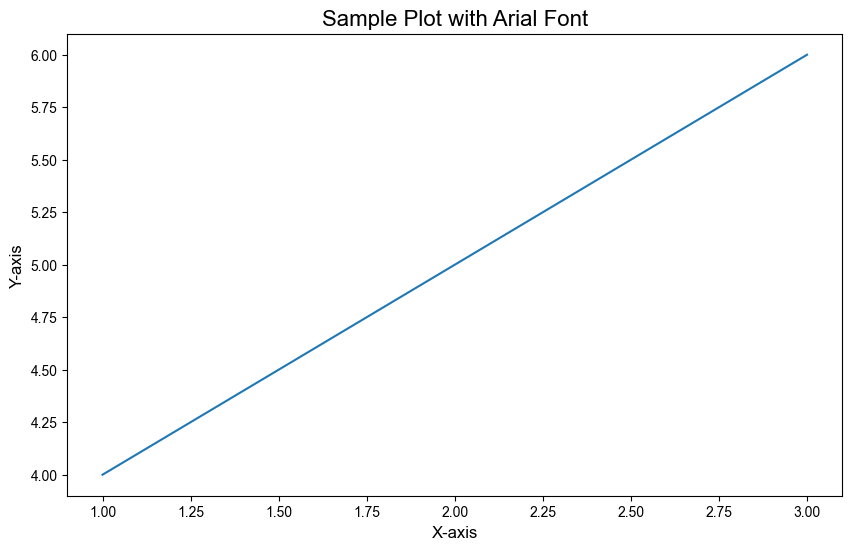

In [1]:
# Install fonttools if not already installed
!pip install fonttools

# Create a directory for fonts
!mkdir -p /usr/share/fonts/truetype/arial

# Download Arial font (using a sample source - you might need a legitimate font source)
# Note: This is a demonstration. For production use, obtain Arial legally
!wget -O /usr/share/fonts/truetype/arial/Arial.ttf "https://github.com/matomo-org/travis-scripts/raw/master/fonts/Arial.ttf"

# Refresh the font cache
!fc-cache -f -v

# Verify the font is installed
!fc-list | grep Arial

# Python code to use Arial in matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Register the font
font_path = '/usr/share/fonts/truetype/arial/Arial.ttf'
fm.fontManager.addfont(font_path)

# Set Arial as the default font
plt.rcParams['font.family'] = 'Arial'

# Example plot using Arial
plt.figure(figsize=(10, 6))
plt.title('Sample Plot with Arial Font', fontsize=16)
plt.xlabel('X-axis', fontsize=12)
plt.ylabel('Y-axis', fontsize=12)
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

# Setup and Imports


In [2]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, OneCycleLR
from tqdm import tqdm
import pandas as pd
from collections import Counter
import random
import os
from sklearn.metrics import precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')
# Create output directories
os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
# Configuration Parameters
---

In [3]:
CONFIG = {
    'ester_representative': 'isoamyl acetate at 0.3% v/v',
    # Model architecture
    'feature_dim': 1024,
    'hidden_dim_1': 512,
    'hidden_dim_2': 256,
    'dropout_rate': 0.25,     # Adjusted from 0.3
    'num_residual_blocks': 3, # Increased from 2

    # Training parameters
    'batch_size': 128,         # Smaller batch size for better generalization
    'learning_rate': 0.0001,  # Decreased from 0.001
    'weight_decay': 1e-4,
    'num_epochs': 150,
    'patience': 30,

    # Data augmentation
    'use_mixup': True,
    'mixup_alpha': 0.2,


    # Ensemble settings
    'num_folds': 5,
    'use_ensemble': True
}

---
# Data Loading and Preprocessing Functions
---

In [4]:
import os
import pickle
from collections import Counter

import numpy as np
import pandas as pd


def load_data(
    ob_pkl_path: str,
    pcx_pkl_path: str,
    meta_csv_path: str,
    selected_bands: list = None,
    ext_ob_pkl_path: str = None,
    ext_pcx_pkl_path: str = None,
    ext_meta_csv_path: str = None,
):
    """
    Load OB/PCx band‑power pickles and metadata CSV, optionally append extended pickles,
    and optionally select a subset of bands.

    Returns:
      X_ob:      OB array (n_samples, n_channels, n_selected_bands)
      X_pcx:     PCx array (n_samples, n_channels, n_selected_bands)
      y:         1D array of labels (odor names), length = total samples
      band_names: List of the selected band names
    """
    def _load_pkl(path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        if 'band_powers' not in data or 'band_names' not in data:
            raise KeyError(f"Pickle {path} must contain 'band_powers' and 'band_names'")
        return data['band_powers'], data['band_names']

    # 1) load primary pickles
    print("Loading primary band‑power pickles...")
    X_ob, bands_ob = _load_pkl(ob_pkl_path)
    X_pcx, bands_pcx = _load_pkl(pcx_pkl_path)
    if bands_ob != bands_pcx:
        raise ValueError("OB and PCx pickles have different band names")
    band_names = bands_ob

    # 2) load metadata
    print("Loading metadata CSV...")
    meta = pd.read_csv(meta_csv_path)
    if 'odor_name' not in meta.columns:
        raise KeyError(f"'odor_name' column missing in {meta_csv_path}")
    y = meta['odor_name'].to_numpy()

    # 3) optionally append extended data
    if ext_ob_pkl_path and ext_pcx_pkl_path:
        print("Loading extended pickles...")
        X_ob_ext, bands_ob_ext = _load_pkl(ext_ob_pkl_path)
        X_pcx_ext, bands_pcx_ext = _load_pkl(ext_pcx_pkl_path)
        if bands_ob_ext != band_names or bands_pcx_ext != band_names:
            raise ValueError("Extended pickles must use the same band_names as primary")
        # load extended labels
        if ext_meta_csv_path:
            meta_ext = pd.read_csv(ext_meta_csv_path)
            if 'odor_name' not in meta_ext.columns:
                raise KeyError(f"'odor_name' column missing in {ext_meta_csv_path}")
            y_ext = meta_ext['odor_name'].to_numpy()
        else:
            # assume primary CSV has extended labels appended at end
            total = X_ob.shape[0] + X_ob_ext.shape[0]
            if len(y) < total:
                raise ValueError("Not enough rows in primary CSV for extended data; set EXT_META_CSV_PATH")
            y_ext = y[len(y) : len(y) + X_ob_ext.shape[0]]

        # concatenate along first axis
        X_ob = np.concatenate([X_ob, X_ob_ext], axis=0)
        X_pcx = np.concatenate([X_pcx, X_pcx_ext], axis=0)
        y = np.concatenate([y, y_ext], axis=0)

    # 4) consistency checks
    for arr, name in [(X_ob, "OB"), (X_pcx, "PCx")]:
        if arr.ndim != 3:
            raise ValueError(f"{name} array must be 3D, got shape {arr.shape}")
    if X_ob.shape[0] != len(y):
        raise ValueError(f"Number of samples in OB ({X_ob.shape[0]}) != labels ({len(y)})")

    # 5) optional band selection
    if selected_bands:
        idx_map = {b: i for i, b in enumerate(band_names)}
        indices = []
        for b in selected_bands:
            if b not in idx_map:
                raise ValueError(f"Band '{b}' not found. Available: {band_names}")
            indices.append(idx_map[b])
        X_ob  = X_ob[:,  :, indices]
        X_pcx = X_pcx[:, :, indices]
        band_names = [band_names[i] for i in indices]

    # 6) report
    print(f"OB shape:   {X_ob.shape}")
    print(f"PCx shape:  {X_pcx.shape}")
    print(f"Samples:    {len(y)}")
    print(f"Bands used: {band_names}")
    print(f"Distribution: {Counter(y)}")



    return X_ob, X_pcx, y, band_names





---
# Data Preprocessing - Creating Balanced Odor Groups
---

In [5]:
import numpy as np
import random
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

def create_balanced_odor_groups(X_ob, X_pcx, y,
                                selected_ester=CONFIG['ester_representative']):
    # Mapping from full odor string to group label
    group_mapping = {
        '2-hexanone at 0.3% v/v': '2-hexanone',
        'hexanal at 0.3% v/v':   'hexanal',
        'mineral oil':           'mineral oil',
        'ethyl acetate at 0.3% v/v': 'ethyl acetate',
        'ethyl butyrate at 0.3% v/v': 'ethyl butyrate',
        'ethyl tiglate at 0.3% v/v': 'ethyl tiglate',
        'isoamyl acetate at 0.3% v/v': 'isoamyl acetate'
    }

    # Valid esters for filtering
    valid_esters = [
        'ethyl acetate at 0.3% v/v',
        'ethyl butyrate at 0.3% v/v',
        'ethyl tiglate at 0.3% v/v',
        'isoamyl acetate at 0.3% v/v'
    ]
    if selected_ester is not None and selected_ester not in valid_esters:
        selected_ester = None

    # Collect indices by group
    ketones_indices = []
    aldehydes_indices = []
    no_smell_indices = []
    esters_indices = {e: [] for e in valid_esters}

    for i, odor in enumerate(y):
        if odor == '2-hexanone at 0.3% v/v':
            ketones_indices.append(i)
        elif odor == 'hexanal at 0.3% v/v':
            aldehydes_indices.append(i)
        elif odor == 'mineral oil':
            no_smell_indices.append(i)
        elif odor in esters_indices:
            esters_indices[odor].append(i)

    # Outlier removal
    def remove_outliers(indices, X, contamination=0.05):
        if len(indices) <= 5:
            return indices
        X_sub = X[indices].reshape(len(indices), -1)
        iso = IsolationForest(contamination=contamination, random_state=42)
        preds = iso.fit_predict(X_sub)
        return [indices[i] for i, p in enumerate(preds) if p == 1]

    ketones_indices = remove_outliers(ketones_indices, X_ob)
    aldehydes_indices = remove_outliers(aldehydes_indices, X_ob)
    no_smell_indices = remove_outliers(no_smell_indices, X_ob)
    for ester in esters_indices:
        esters_indices[ester] = remove_outliers(
            esters_indices[ester], X_ob, contamination=0.03)

    # K-means based sampling
    def cluster_based_sampling(indices, X, n_samples, n_clusters=10):
        if len(indices) <= n_samples:
            return indices
        X_sub = X[indices].reshape(len(indices), -1)
        k = min(n_clusters, n_samples, len(indices))
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_sub)
        per_cluster = n_samples // k
        rem = n_samples % k
        selected = []
        for c in range(k):
            members = [i for i, lab in enumerate(labels) if lab == c]
            if not members:
                continue
            center = kmeans.cluster_centers_[c]
            dists = np.linalg.norm(X_sub[members] - center, axis=1)
            order = np.argsort(dists)
            take = per_cluster + (1 if c < rem else 0)
            for idx in order[:take]:
                selected.append(indices[members[idx]])
        if len(selected) < n_samples:
            remaining = set(indices) - set(selected)
            selected += random.sample(list(remaining), n_samples - len(selected))
        return selected[:n_samples]

    # Determine balanced target size
    if selected_ester:
        ester_count = len(esters_indices[selected_ester])
    else:
        ester_count = sum(len(v) for v in esters_indices.values())
    min_size = min(len(ketones_indices), len(aldehydes_indices),
                   len(no_smell_indices), ester_count)
    target = int(min_size * 0.95)

    # Sample each group
    ketones_final = cluster_based_sampling(
        ketones_indices, X_ob, target)
    aldehydes_final = cluster_based_sampling(
        aldehydes_indices, X_ob, target)
    no_smell_final = cluster_based_sampling(
        no_smell_indices, X_ob, target)

    esters_final = []
    if selected_ester:
        esters_final = cluster_based_sampling(
            esters_indices[selected_ester], X_ob,
            min(target, len(esters_indices[selected_ester])),
            n_clusters=min(10, len(esters_indices[selected_ester])))
    else:
        ester_types = list(esters_indices)
        per = target // len(ester_types)
        rem = target % len(ester_types)
        for i, odor in enumerate(ester_types):
            cnt = per + (1 if i < rem else 0)
            if esters_indices[odor]:
                esters_final += cluster_based_sampling(
                    esters_indices[odor], X_ob,
                    min(cnt, len(esters_indices[odor])),
                    n_clusters=min(5, len(esters_indices[odor])))

    # Combine and build outputs
    all_idx = ketones_final + aldehydes_final + no_smell_final + esters_final
    X_ob_balanced  = X_ob[all_idx]
    X_pcx_balanced = X_pcx[all_idx]
    y_original     = np.array([y[i] for i in all_idx])
    y_balanced     = np.array([group_mapping[o] for o in y_original])

    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y_balanced)

    return (
        X_ob_balanced,
        X_pcx_balanced,
        y_balanced,
        y_encoded,
        y_original,
        group_mapping,
        encoder
    )

---
# Data Normalization and Feature Enhancement
---


In [6]:
import numpy as np
from typing import Optional, Tuple

def normalize_data_robust(
    X_train: np.ndarray,
    X_val: Optional[np.ndarray] = None,
    X_test: Optional[np.ndarray] = None,
    clip_value: float = 8.0,
    min_iqr: float = 1e-5
) -> Tuple[np.ndarray, Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Robust normalization that handles outliers and ensures stability across channels and frequency bands.

    For each feature in the training set, the function subtracts the median and divides by the
    interquartile range (IQR), with a replacement for very small IQR values. The same transformation
    is applied to the validation and test sets.

    Parameters:
    -----------
    X_train : np.ndarray
        Training data array.
    X_val : Optional[np.ndarray], default=None
        Validation data array.
    X_test : Optional[np.ndarray], default=None
        Test data array.
    clip_value : float, default=8.0
        Maximum absolute value after normalization for clipping.
    min_iqr : float, default=1e-5
        Minimum IQR value to avoid division by zero.

    Returns:
    --------
    Tuple[np.ndarray, Optional[np.ndarray], Optional[np.ndarray]]
        Normalized training, validation, and test arrays.
    """
    # Helper function to perform normalization on any given data
    def _normalize(X: np.ndarray, medians: np.ndarray, iqr: np.ndarray) -> np.ndarray:
        X_2d = X.reshape(X.shape[0], -1)
        normalized = (X_2d - medians) / iqr
        normalized = np.clip(normalized, -clip_value, clip_value)
        return normalized.reshape(X.shape)

    # Flatten training array for feature-wise statistics
    X_train_flat = X_train.reshape(X_train.shape[0], -1)

    # Robust statistics: subtract median and divide by IQR
    medians = np.median(X_train_flat, axis=0)
    q75, q25 = np.percentile(X_train_flat, [75, 25], axis=0)
    iqr = q75 - q25
    # Ensure IQR is not too small
    iqr = np.maximum(iqr, min_iqr)

    # Normalize training data
    X_train_norm = _normalize(X_train, medians, iqr)

    # Normalize validation and test data using training statistics (if provided)
    X_val_norm = _normalize(X_val, medians, iqr) if X_val is not None else None
    X_test_norm = _normalize(X_test, medians, iqr) if X_test is not None else None

    return X_train_norm, X_val_norm, X_test_norm

def enhance_features_advanced(X: np.ndarray) -> np.ndarray:
    """
    Advanced feature transformation that captures non-linear relationships and emphasizes
    distinctive patterns for improved classification.

    The transformation pipeline includes:
    1. Log transformation to compress dynamic range (with sign preservation).
    2. Hyperbolic tangent transformation to enhance mid-range values.
    3. Sigmoid transformation to further normalizes the extreme values.
    4. A weighted combination of the tanh and sigmoid outputs.

    Parameters:
    -----------
    X : np.ndarray
        Input feature array.

    Returns:
    --------
    np.ndarray
        Enhanced feature array.
    """
    # Apply log scaled transformation with sign preservation
    log_transformed = np.sign(X) * np.log(np.abs(X) + 1)

    # Emphasize mid-range by scaling then applying tanh
    alpha = 0.5
    tanh_transformed = np.tanh(alpha * log_transformed)

    # Sigmoid transformation to capture non-linear scaling of extreme values
    sigmoid_transformed = 1 / (1 + np.exp(-log_transformed))

    # Combine using weighted average to preserve both transformations
    enhanced = 0.7 * tanh_transformed + 0.3 * sigmoid_transformed

    return enhanced

---
# Data Augmentation Functions
---


In [7]:

def spectral_augment(x, freq_mask_param=2, time_mask_param=2, num_masks=2):
    """
    Apply SpecAugment-inspired transformations to the input data.
    This is especially effective for frequency-domain data like our band powers.

    Args:
        x: Input tensor of shape [batch, channels, bands]
        freq_mask_param: Maximum width of frequency mask
        time_mask_param: Maximum width of time mask
        num_masks: Number of masks to apply

    Returns:
        Augmented tensor of the same shape
    """
    y = x.clone()
    batch_size, num_channels, num_bands = y.shape

    # Apply frequency masks (across bands)
    for i in range(num_masks):
        for j in range(batch_size):
            f = random.randint(0, freq_mask_param)
            f_zero = random.randint(0, num_bands - f)
            y[j, :, f_zero:f_zero + f] = 0

    # Apply time masks (across channels)
    for i in range(num_masks):
        for j in range(batch_size):
            t = random.randint(0, time_mask_param)
            t_zero = random.randint(0, num_channels - t)
            y[j, t_zero:t_zero + t, :] = 0

    return y

def mixup_data(x_ob, x_pcx, y, alpha=0.2):
    """
    Applies mixup augmentation to dual input data.

    Args:
        x_ob: OB input tensor
        x_pcx: PCx input tensor
        y: Target labels
        alpha: Mixup alpha parameter

    Returns:
        Mixed inputs and targets
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x_ob.size()[0]
    index = torch.randperm(batch_size).to(x_ob.device)

    mixed_x_ob = lam * x_ob + (1 - lam) * x_ob[index, :]
    mixed_x_pcx = lam * x_pcx + (1 - lam) * x_pcx[index, :]
    y_a, y_b = y, y[index]

    return mixed_x_ob, mixed_x_pcx, y_a, y_b, lam

def create_perfectly_balanced_splits(X_ob, X_pcx, y_encoded, test_size=0.15, val_size=0.2):
    """
    Create train, validation, and test splits with exactly equal samples per class
    """
    num_classes = len(np.unique(y_encoded))
    class_indices = [np.where(y_encoded == i)[0] for i in range(num_classes)]

    # Find minimum class size to ensure balance
    min_class_size = min(len(indices) for indices in class_indices)

    # Calculate exact split sizes
    num_test_per_class = int(min_class_size * test_size)
    num_val_per_class = int(min_class_size * val_size * (1 - test_size))
    num_train_per_class = min_class_size - num_test_per_class - num_val_per_class

    print(f"Creating balanced splits with {num_train_per_class} train, "
          f"{num_val_per_class} validation, and {num_test_per_class} test samples per class")

    # Initialize index arrays
    train_indices = []
    val_indices = []
    test_indices = []

    # For each class, randomly sample for each split
    for class_idx in range(num_classes):
        indices = class_indices[class_idx].copy()
        np.random.shuffle(indices)

        test_indices.extend(indices[:num_test_per_class])
        val_indices.extend(indices[num_test_per_class:num_test_per_class+num_val_per_class])
        train_indices.extend(indices[num_test_per_class+num_val_per_class:
                                    num_test_per_class+num_val_per_class+num_train_per_class])

    # Create the splits
    X_ob_train = X_ob[train_indices]
    X_pcx_train = X_pcx[train_indices]
    y_train = y_encoded[train_indices]

    X_ob_val = X_ob[val_indices]
    X_pcx_val = X_pcx[val_indices]
    y_val = y_encoded[val_indices]

    X_ob_test = X_ob[test_indices]
    X_pcx_test = X_pcx[test_indices]
    y_test = y_encoded[test_indices]

    # Verify class distribution
    print("\nClass distribution in splits:")
    for i in range(num_classes):
        train_count = np.sum(y_train == i)
        val_count = np.sum(y_val == i)
        test_count = np.sum(y_test == i)
        print(f"  Class {i}: {train_count} train, {val_count} validation, {test_count} test")

    return X_ob_train, X_ob_val, X_ob_test, X_pcx_train, X_pcx_val, X_pcx_test, y_train, y_val, y_test


---
# Model Architecture Components
---

In [8]:

class ChannelAttention(nn.Module):
    """Improved channel attention module with squeeze-and-excitation"""
    def __init__(self, channels, reduction=4):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)

        # Shared MLP for efficiency and stability
        self.mlp = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _ = x.shape

        # Average pooling
        avg_out = self.avg_pool(x).view(b, c)
        avg_out = self.mlp(avg_out)

        # Max pooling
        max_out = self.max_pool(x).view(b, c)
        max_out = self.mlp(max_out)

        # Combine and apply sigmoid activation
        out = avg_out + max_out
        attention = self.sigmoid(out).view(b, c, 1)

        return x * attention

class SpatialAttention(nn.Module):
    """Enhanced spatial attention module"""
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = 3 if kernel_size == 7 else 1

        # More filters for better feature extraction
        self.conv1 = nn.Conv1d(2, 8, kernel_size=kernel_size, padding=padding)
        self.bn = nn.BatchNorm1d(8)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(8, 1, kernel_size=3, padding=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Create feature maps from average and max pooling
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        y = torch.cat([avg_out, max_out], dim=1)

        # Process through convolutional layers
        y = self.relu(self.bn(self.conv1(y)))
        y = self.conv2(y)
        attention = self.sigmoid(y)

        return x * attention

class ResidualBlock(nn.Module):
    """Enhanced residual block with pre-activation and SE attention"""
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        # Pre-activation style residual block
        self.bn1 = nn.BatchNorm1d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3,
                              stride=stride, padding=1, bias=False)

        self.bn2 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3,
                              stride=1, padding=1, bias=False)

        # Channel attention
        self.ca = ChannelAttention(out_channels)

        # Skip connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1,
                         stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        identity = x

        out = self.bn1(x)
        out = self.relu(out)
        out = self.conv1(out)

        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)

        # Apply channel attention
        out = self.ca(out)

        # Add skip connection
        out += self.shortcut(identity)

        return out

class RegionSpecificNet(nn.Module):
    """Enhanced network for processing either OB or PCx data without a hard limit on residual blocks"""
    def __init__(self, num_channels, num_bands, feature_dim=512, dropout_rate=0.25, num_residual_blocks=3):
        super(RegionSpecificNet, self).__init__()
        # Channel attention to focus on important channels
        self.channel_attention = ChannelAttention(num_channels)
        self.spatial_attention = SpatialAttention()
        # Initial convolutional block with larger filters
        self.conv1 = nn.Sequential(
            nn.Conv1d(num_channels, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Conv1d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        # Create residual blocks dynamically.
        self.residual_blocks = nn.ModuleList()
        in_channels = 64
        # For each residual block, double the number of channels and use a stride of 2.
        for i in range(num_residual_blocks):
            out_channels = in_channels * 2
            self.residual_blocks.append(
                ResidualBlock(in_channels, out_channels, stride=2)
            )
            in_channels = out_channels

        # Spatial attention to refine features
        self.spatial_attn = SpatialAttention()

        # Global pooling with both average and max
        self.global_avgpool = nn.AdaptiveAvgPool1d(1)
        self.global_maxpool = nn.AdaptiveMaxPool1d(1)

        # Feature dimension after pooling (concatenation of avg and max pooling)
        self.feature_size = in_channels * 2

        # Feature projection network
        self.feature_projection = nn.Sequential(
            nn.Linear(self.feature_size, self.feature_size // 2),
            nn.BatchNorm1d(self.feature_size // 2),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate),
            nn.Linear(self.feature_size // 2, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate * 0.5)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        x = self.conv1(x)
        for block in self.residual_blocks:
            x = block(x)
        x = self.spatial_attn(x)
        avg_x = self.global_avgpool(x).view(x.size(0), -1)
        max_x = self.global_maxpool(x).view(x.size(0), -1)
        x = torch.cat([avg_x, max_x], dim=1)
        features = self.feature_projection(x)
        return features


---
# Main Model Architecture
---


In [9]:


class DualRegionNet(nn.Module):
    """Enhanced network that processes both OB and PCx data with improved fusion"""
    def __init__(self, ob_channels, ob_bands, pcx_channels, pcx_bands,
                 num_classes, dropout_rate=0.25):
        super(DualRegionNet, self).__init__()
        self.feature_dim = CONFIG['feature_dim']


        self.ob_net = RegionSpecificNet(
            ob_channels, ob_bands, self.feature_dim, dropout_rate,
            num_residual_blocks=CONFIG['num_residual_blocks']
        )
        self.pcx_net = RegionSpecificNet(
            pcx_channels, pcx_bands, self.feature_dim, dropout_rate,
            num_residual_blocks=CONFIG['num_residual_blocks']
        )
        self.fusion_attention = nn.Sequential(
            nn.Linear(self.feature_dim * 2, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2),
            nn.Softmax(dim=1)
        )
        self.combined_dim = self.feature_dim
        self.classifier = nn.Sequential(
            nn.Linear(self.combined_dim, CONFIG['hidden_dim_1']),
            nn.BatchNorm1d(CONFIG['hidden_dim_1']),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate),

            nn.Linear(CONFIG['hidden_dim_1'], CONFIG['hidden_dim_2']),
            nn.BatchNorm1d(CONFIG['hidden_dim_2']),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate * 0.8),

            nn.Linear(CONFIG['hidden_dim_2'], CONFIG['hidden_dim_3'] // 2),
            nn.BatchNorm1d(CONFIG['hidden_dim_3'] // 2),  # Fixed: was CONFIG['hidden_dim_3']
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate * 0.8),

            nn.Linear(CONFIG['hidden_dim_3'] // 2, CONFIG['hidden_dim_4']),  # Fixed: input dim
            nn.BatchNorm1d(CONFIG['hidden_dim_4']),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate * 0.8),

            nn.Linear(CONFIG['hidden_dim_4'], CONFIG['hidden_dim_4'] // 2),
            nn.BatchNorm1d(CONFIG['hidden_dim_4'] // 2),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout_rate * 0.6),

            nn.Linear(CONFIG['hidden_dim_4'] // 2, num_classes)
        )
        self.skip = nn.Linear(self.combined_dim, num_classes)

    def forward(self, ob_x, pcx_x):
        ob_features = self.ob_net(ob_x)
        pcx_features = self.pcx_net(pcx_x)
        concat_features = torch.cat([ob_features, pcx_features], dim=1)
        attention_weights = self.fusion_attention(concat_features)
        combined = attention_weights[:, 0].unsqueeze(1) * ob_features + \
                   attention_weights[:, 1].unsqueeze(1) * pcx_features
        skip_output = self.skip(combined)
        main_output = self.classifier(combined)
        output = main_output + skip_output
        return output

    def get_region_features(self, ob_x, pcx_x):
        with torch.no_grad():
            ob_features = self.ob_net(ob_x)
            pcx_features = self.pcx_net(pcx_x)
        return ob_features, pcx_features

    def get_attention_weights(self, ob_x, pcx_x):
        with torch.no_grad():
            ob_features = self.ob_net(ob_x)
            pcx_features = self.pcx_net(pcx_x)
            concat_features = torch.cat([ob_features, pcx_features], dim=1)
            attention_weights = self.fusion_attention(concat_features)
        return attention_weights.cpu().numpy()

---
# Loss Function and Dataset
---

In [10]:

class FocalLoss(nn.Module):
    """Focal Loss for dealing with class imbalance"""
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            loss = alpha_t * loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

class DualInputDataset(torch.utils.data.Dataset):
    """Dataset class to handle both OB and PCx inputs"""
    def __init__(self, ob_data, pcx_data, labels):
        self.ob_data = ob_data
        self.pcx_data = pcx_data
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.ob_data[idx], self.pcx_data[idx], self.labels[idx]

---
# Training and Evaluation Functions
---

In [11]:

def train_epoch(model, train_loader, criterion, optimizer, device, config):
    """Train for one epoch with enhanced augmentation"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc="Training")
    for batch in pbar:
        # For dual input model
        ob_inputs, pcx_inputs, targets = batch[0].to(device), batch[1].to(device), batch[2].to(device)

        # Apply SpecAugment if enabled
        if config['use_spectral_augment']:
            if random.random() < 0.5:  # 50% chance to apply
                ob_inputs = spectral_augment(
                    ob_inputs,
                    freq_mask_param=config['freq_mask_param'],
                    time_mask_param=config['time_mask_param']
                )
            if random.random() < 0.5:  # 50% chance to apply
                pcx_inputs = spectral_augment(
                    pcx_inputs,
                    freq_mask_param=config['freq_mask_param'],
                    time_mask_param=config['time_mask_param']
                )

        # Apply mixup augmentation if enabled
        if config['use_mixup'] and random.random() < 0.7:  # 70% chance to apply
            mixed_ob_inputs, mixed_pcx_inputs, targets_a, targets_b, lam = mixup_data(
                ob_inputs, pcx_inputs, targets, alpha=config['mixup_alpha']
            )
            use_mixup = True
        else:
            mixed_ob_inputs, mixed_pcx_inputs = ob_inputs, pcx_inputs
            targets_a, targets_b = targets, None
            lam = 1.0
            use_mixup = False

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(mixed_ob_inputs, mixed_pcx_inputs)

        # Calculate loss
        if use_mixup:
            loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)
        else:
            loss = criterion(outputs, targets)

        # Backward pass and optimize
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        # Statistics
        running_loss += loss.item()

        # For accuracy calculation, we use the prediction directly even with mixup
        with torch.no_grad():
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'loss': running_loss / (pbar.n + 1),
            'acc': 100. * correct / total if total > 0 else 0
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total if total > 0 else 0

    return epoch_loss, epoch_acc

def validate(model, val_loader, criterion, device):
    """Validate model on validation set"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in val_loader:
            ob_inputs, pcx_inputs, targets = batch[0].to(device), batch[1].to(device), batch[2].to(device)

            # Forward pass
            outputs = model(ob_inputs, pcx_inputs)
            loss = criterion(outputs, targets)

            # Statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100. * correct / total

    return val_loss, val_acc

def test_time_augmentation(model, ob_inputs, pcx_inputs, num_augmentations=10):
    """Apply multiple augmentations at test time and average results"""
    model.eval()
    all_predictions = []

    # Original prediction
    with torch.no_grad():
        outputs = model(ob_inputs, pcx_inputs)
        probs = F.softmax(outputs, dim=1)
        all_predictions.append(probs)

    # Augmented predictions
    for _ in range(num_augmentations - 1):
        # Create augmented versions
        aug_ob_inputs = ob_inputs.clone()
        aug_pcx_inputs = pcx_inputs.clone()

        # Add small random noise
        ob_noise = torch.randn_like(aug_ob_inputs) * 0.02
        pcx_noise = torch.randn_like(aug_pcx_inputs) * 0.02

        aug_ob_inputs = aug_ob_inputs + ob_noise
        aug_pcx_inputs = aug_pcx_inputs + pcx_noise

        with torch.no_grad():
            aug_outputs = model(aug_ob_inputs, aug_pcx_inputs)
            aug_probs = F.softmax(aug_outputs, dim=1)
            all_predictions.append(aug_probs)

    # Average predictions
    avg_predictions = torch.stack(all_predictions).mean(0)
    return avg_predictions

def train_model(model, train_loader, val_loader, config, fold=None):
    """Train model with enhanced techniques"""
    num_epochs = config['num_epochs']
    patience = config['patience']
    lr = config['learning_rate']
    weight_decay = config['weight_decay']

    # Initialize criterion and optimizer
    criterion = FocalLoss(gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Initialize learning rate scheduler (OneCycleLR for super-convergence)
    scheduler = OneCycleLR(
        optimizer,
        max_lr=lr * 10,
        steps_per_epoch=len(train_loader),
        epochs=num_epochs,
        pct_start=0.3,
        anneal_strategy='cos'
    )

    best_val_acc = 0
    best_model_state = None
    patience_counter = 0

    # For recording history
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    fold_str = f"Fold {fold}: " if fold is not None else ""

    for epoch in range(num_epochs):
        # Train for one epoch
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, config)

        # Update learning rate
        if isinstance(scheduler, OneCycleLR):
            # OneCycleLR is updated after each batch, so we don't update it here
            pass
        else:
            scheduler.step()

        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        # Record history
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # Print progress
        print(f"{fold_str}Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%, "
              f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")

        # Check if this is the best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"{fold_str}New best validation accuracy: {best_val_acc:.2f}%")
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print(f"{fold_str}Early stopping triggered after epoch {epoch+1}")
            break

    # Load best model
    model.load_state_dict(best_model_state)

    # Plot training curves if not in ensemble mode
    if fold is None:
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Val Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.title('Loss Curves')

        plt.subplot(1, 2, 2)
        plt.plot(train_accs, label='Train Acc')
        plt.plot(val_accs, label='Val Acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.title('Accuracy Curves')

        plt.tight_layout()
        plt.savefig('figures/training_curves.png', dpi=300)

    return model, best_val_acc, (train_losses, train_accs, val_losses, val_accs)
def evaluate_model(model, test_loader, label_encoder, device, use_tta=True, return_attention=True):
    """Evaluate model on test set with optional test-time augmentation and extract attention weights."""
    model.eval()
    all_preds = []
    all_targets = []
    all_probs = []
    all_region_attn = []

    with torch.no_grad():
        for batch in test_loader:
            ob_inputs, pcx_inputs, targets = batch[0].to(device), batch[1].to(device), batch[2].to(device)

            # Apply test-time augmentation if enabled
            if use_tta:
                probs = test_time_augmentation(model, ob_inputs, pcx_inputs)
            else:
                outputs = model(ob_inputs, pcx_inputs)
                probs = F.softmax(outputs, dim=1)

            # Get predictions
            _, preds = probs.max(1)

            # Store results
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            if return_attention:
                # Extract regional attention weights
                region_attn = model.get_attention_weights(ob_inputs, pcx_inputs)  # shape: [batch_size, 2]
                all_region_attn.extend(region_attn)

    # Convert to numpy arrays
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)
    all_region_attn = np.array(all_region_attn) if return_attention else None

    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(all_targets, all_preds, target_names=label_encoder.classes_))

    # Plot confusion matrix
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=label_encoder.classes_,
               yticklabels=label_encoder.classes_)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig('figures/confusion_matrix.png', dpi=300)

    # Return metrics and predictions (+ attention)
    return {
        'accuracy': accuracy,
        'predictions': all_preds,
        'targets': all_targets,
        'probabilities': all_probs,
        'region_attention': all_region_attn
    }



# Model Attributes

In [12]:
def get_channel_attention(model, data_loader, device):
    """Extract per-sample channel attention weights for OB and PCX regions."""
    model.eval()
    ob_attns, pcx_attns = [], []

    with torch.no_grad():
        for batch in data_loader:
            ob_x, pcx_x, _ = batch[0].to(device), batch[1].to(device), batch[2]

            # OB region channel attention
            ca_ob = model.ob_net.channel_attention
            b, c, _ = ob_x.shape
            avg_out = ca_ob.avg_pool(ob_x).view(b, c)
            avg_out = ca_ob.mlp(avg_out)
            max_out = ca_ob.max_pool(ob_x).view(b, c)
            max_out = ca_ob.mlp(max_out)
            attn_ob = ca_ob.sigmoid(avg_out + max_out).cpu().numpy()  # [batch, n_channels]
            ob_attns.append(attn_ob)

            # PCX region channel attention
            ca_pcx = model.pcx_net.channel_attention
            b, c, _ = pcx_x.shape
            avg_out = ca_pcx.avg_pool(pcx_x).view(b, c)
            avg_out = ca_pcx.mlp(avg_out)
            max_out = ca_pcx.max_pool(pcx_x).view(b, c)
            max_out = ca_pcx.mlp(max_out)
            attn_pcx = ca_pcx.sigmoid(avg_out + max_out).cpu().numpy()
            pcx_attns.append(attn_pcx)

    ob_attns = np.vstack(ob_attns)
    pcx_attns = np.vstack(pcx_attns)
    return ob_attns, pcx_attns  # [num_samples, n_channels] each

def get_spatial_attention(model, data_loader, device):
    """Extract per-sample spatial attention weights for OB and PCX regions."""
    model.eval()
    ob_attns, pcx_attns = [], []

    with torch.no_grad():
        for batch in data_loader:
            ob_x, pcx_x, _ = batch[0].to(device), batch[1].to(device), batch[2]

            # OB region spatial attention
            sa_ob = model.ob_net.spatial_attn
            avg_out = torch.mean(ob_x, dim=1, keepdim=True)
            max_out, _ = torch.max(ob_x, dim=1, keepdim=True)
            y = torch.cat([avg_out, max_out], dim=1)
            y = sa_ob.relu(sa_ob.bn(sa_ob.conv1(y)))
            y = sa_ob.conv2(y)
            attn_ob = sa_ob.sigmoid(y).cpu().numpy().squeeze(1)  # [batch, n_bands]
            ob_attns.append(attn_ob)

            # PCX region spatial attention
            sa_pcx = model.pcx_net.spatial_attn
            avg_out = torch.mean(pcx_x, dim=1, keepdim=True)
            max_out, _ = torch.max(pcx_x, dim=1, keepdim=True)
            y = torch.cat([avg_out, max_out], dim=1)
            y = sa_pcx.relu(sa_pcx.bn(sa_pcx.conv1(y)))
            y = sa_pcx.conv2(y)
            attn_pcx = sa_pcx.sigmoid(y).cpu().numpy().squeeze(1)
            pcx_attns.append(attn_pcx)

    ob_attns = np.vstack(ob_attns)
    pcx_attns = np.vstack(pcx_attns)
    return ob_attns, pcx_attns  # [num_samples, n_bands] each

def get_region_features(model, data_loader, device):
    """Get OB/PCX feature embeddings for all test samples."""
    model.eval()
    ob_feats, pcx_feats = [], []
    with torch.no_grad():
        for batch in data_loader:
            ob_x, pcx_x, _ = batch[0].to(device), batch[1].to(device), batch[2]
            ob_f, pcx_f = model.get_region_features(ob_x, pcx_x)
            ob_feats.append(ob_f.cpu().numpy())
            pcx_feats.append(pcx_f.cpu().numpy())
    ob_feats = np.vstack(ob_feats)
    pcx_feats = np.vstack(pcx_feats)
    return ob_feats, pcx_feats  # [num_samples, feature_dim] each
def get_classifier_weights(model):
    """Get the weights of the last classifier linear layer."""
    # Assuming last layer is model.classifier[-1] (Linear)
    final_linear = model.classifier[-1]
    weights = final_linear.weight.detach().cpu().numpy()  # [num_classes, prev_dim]
    bias = final_linear.bias.detach().cpu().numpy() if final_linear.bias is not None else None
    return weights, bias

---
# Visualization and Analysis Functions
---


In [13]:
def create_nature_compliant_figure(
    X_ob,
    X_pcx,
    y_test,
    ensemble_preds,
    ensemble_probs,
    label_encoder,
    region_attention=None,
    # Removed channel-related arguments as requested
    ob_spatial_attention=None,
    pcx_spatial_attention=None,
    ob_features=None,
    pcx_features=None,
    test_indices=None,
    plot_dir="ensemble_plots",
    save_figure=True,
    fig_name="comprehensive_analysis_nature_no_titles.pdf",  # Save as PDF by default
):
    """
    Multi-panel figure for deep model interpretability, Nature-style, with advanced legends and annotations.

    Panels:
        A: Confusion Matrix
        B: ROC Curves (per class)
        C: Regional Attention (OB/PCX, per class)
        D: OB Full Band Spatial Attention (heatmap)
        E: PCX Full Band Spatial Attention (heatmap)
        F: OB Normal Band Spatial Attention (heatmap)
        G: PCX Normal Band Spatial Attention (heatmap)
        H: OB Feature Embeddings (t-SNE)
        I: PCX Feature Embeddings (t-SNE)
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.gridspec as gridspec
    from sklearn.metrics import confusion_matrix, roc_curve, auc

    # Define the frequency bands dictionary, including full bands and normal bands.
    frequency_bands = {
        # Delta sub-bands
        'delta':         (0.5,  4),
        'theta':         (4,    8),
        'respiration':   (0.5, 10),
        # Alpha sub-bands
        'alpha_high':    (10,   13),
        'full_alpha':    (8,    13),
        # Beta sub-bands
        'beta_low':      (13,   20),
        'beta_high':     (20,   30),
        'full_beta':     (13,   30),
        # Gamma sub-bands
        'gamma_low':     (30,   50),
        'gamma_mid':     (50,   80),
        'full_gamma':    (30,   80),
        # Gamma high sub-bands
        'gamma_high_low':  (80,   120),
        'gamma_high_high': (120,  160),
        'full_gamma_high': (80,   160),
        # Gamma ultra sub-bands
        'gamma_ultra_low':  (160,  200),
        'gamma_ultra_high': (200,  250),
        'full_gamma_ultra': (160,  250),
        # Epsilon sub-bands
        'epsilon_low':   (250,  400),
        'epsilon_high':  (400,  600),
        'full_epsilon':  (250,  600),
        # Entire spectrum
        'full_spectrum': (0.5,  600),
    }
    # Compute full list of band names in order (e.g., "alpha_high (10-13 Hz)")
    band_names = [f"{k} ({v[0]:.0f}-{v[1]:.0f} Hz)" for k, v in frequency_bands.items()]
    # Also determine which indices are for "full" bands vs "normal" bands.
    band_keys = list(frequency_bands.keys())
    full_indices = [i for i, k in enumerate(band_keys) if k.startswith("full")]
    normal_indices = [i for i, k in enumerate(band_keys) if not k.startswith("full")]
    full_band_names = [band_names[i] for i in full_indices]
    normal_band_names = [band_names[i] for i in normal_indices]

    # For display of channel names (not used anymore, but kept for context)
    channel_names = [f"Ch {i+1}" for i in range(32)]

    sns.set(style="ticks", context="paper", font_scale=1.5)
    plt.rcParams["lines.linewidth"] = 2
    plt.rcParams["lines.markersize"] = 7
    palette = sns.color_palette("colorblind", n_colors=10)

    if save_figure:
        os.makedirs(plot_dir, exist_ok=True)

    if test_indices is not None:
        X_ob_test = X_ob[test_indices]
        X_pcx_test = X_pcx[test_indices]
    else:
        X_ob_test, X_pcx_test = X_ob, X_pcx

    num_classes = ensemble_probs.shape[1]
    ensemble_acc = np.mean(ensemble_preds == y_test)
    class_names = label_encoder.classes_

    # Create a 3x3 grid for the 9 panels.
    fig = plt.figure(figsize=(22, 16))
    gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[1.2, 1, 1])

    # PANEL A: CONFUSION MATRIX
    axA = plt.subplot(gs[0, 0])
    cm = confusion_matrix(y_test, ensemble_preds)
    cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cmap = sns.color_palette("Blues", as_cmap=True)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap=cmap,
        xticklabels=class_names, yticklabels=class_names,
        ax=axA, cbar=True, cbar_kws={"shrink": 0.7}
    )
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axA.text(j + 0.5, i + 0.95, f"{cm_norm[i, j]:.1%}",
                     ha="center", va="center",
                     color="white" if cm_norm[i, j] > 0.5 else "black",
                     fontsize=10, fontweight="bold")
    axA.set_xlabel("Predicted class", fontweight="bold")
    axA.set_ylabel("True class", fontweight="bold")
    axA.set_title("A. Confusion Matrix\n(Top: count, Bottom: row-normalized %)", fontweight="bold", fontsize=13)
    axA.xaxis.set_tick_params(rotation=30)
    axA.yaxis.set_tick_params(rotation=0)

    # PANEL B: ROC CURVES
    axB = plt.subplot(gs[0, 1])
    aucs = []
    for i in range(num_classes):
        y_test_binary = (y_test == i).astype(int)
        y_score = ensemble_probs[:, i]
        fpr, tpr, _ = roc_curve(y_test_binary, y_score)
        roc_auc = auc(fpr, tpr)
        aucs.append(roc_auc)
        sns.lineplot(x=fpr, y=tpr, lw=2, label=f"{class_names[i]} (AUC={roc_auc:.2f})", ax=axB)
    axB.plot([0, 1], [0, 1], "k--", lw=1.0, alpha=0.7, label="Chance")
    axB.set_xlim([0.0, 1.0])
    axB.set_ylim([0.0, 1.05])
    axB.set_xlabel("False Positive Rate")
    axB.set_ylabel("True Positive Rate")
    axB.set_title("B. ROC Curves by Class", fontweight="bold", fontsize=13)
    leg = axB.legend(loc="lower right", fontsize=10, title="Class (AUC)")
    leg.get_frame().set_alpha(0.92)

    # PANEL C: REGIONAL ATTENTION
    axC = plt.subplot(gs[0, 2])
    if region_attention is not None:
        per_class_ob = []
        per_class_pcx = []
        for i in range(num_classes):
            mask = (y_test == i)
            per_class_ob.append(np.mean(region_attention[mask, 0]))
            per_class_pcx.append(np.mean(region_attention[mask, 1]))
        region_contributions_norm = np.stack([per_class_ob, per_class_pcx], axis=1)
        bar1 = axC.bar(class_names, region_contributions_norm[:, 0], width=0.6, label="OB", color=palette[0])
        bar2 = axC.bar(class_names, region_contributions_norm[:, 1], width=0.6,
                       bottom=region_contributions_norm[:, 0], label="PCX", color=palette[1])
        for i, (ob_val, pcx_val) in enumerate(zip(region_contributions_norm[:, 0], region_contributions_norm[:, 1])):
            axC.text(i, ob_val/2, f"{ob_val:.0%}", ha="center", va="center",
                     color="white" if ob_val > 0.3 else "black", fontsize=11, fontweight="bold")
            axC.text(i, ob_val + pcx_val/2, f"{pcx_val:.0%}", ha="center", va="center",
                     color="white" if pcx_val > 0.3 else "black", fontsize=11, fontweight="bold")
        axC.set_xlabel("Class", fontweight="bold")
        axC.set_ylabel("Mean Regional Attention")
        axC.set_ylim(0, 1.05)
        axC.set_title("C. Model Attention: OB vs PCX\nStacked by true class", fontweight="bold", fontsize=13)
        axC.legend(loc="upper right", frameon=True, fontsize=11, title="Region")
        axC.grid(True, axis='y', linestyle='--', alpha=0.4)
    else:
        axC.axis("off")

    # PANEL D: OB FULL BAND SPATIAL ATTENTION - HEATMAP
    axD = plt.subplot(gs[1, 0])
    if ob_spatial_attention is not None:
        # Average over samples then select full band indices.
        mean_ob = np.mean(ob_spatial_attention, axis=0)[full_indices]
        sns.heatmap(
            mean_ob[np.newaxis, :], ax=axD, cmap="Blues", cbar=True,
            xticklabels=full_band_names, yticklabels=['OB Full']
        )
        axD.set_title("D. OB Full Band Attention", fontweight="bold", fontsize=13)
        axD.set_xlabel("Frequency Band", fontweight="bold")
        axD.set_ylabel("")
        axD.tick_params(axis='x', labelrotation=60)
        for i in range(len(full_band_names)):
            if mean_ob[i] > np.percentile(mean_ob, 90):
                axD.annotate(f"{mean_ob[i]:.2f}",
                             xy=(i+0.5, 0.5), xytext=(0, 14),
                             textcoords='offset points', ha='center', va='bottom',
                             fontsize=9, color='black', fontweight="bold")
        axD.collections[0].colorbar.set_label("Attention")
    else:
        axD.axis("off")

    # PANEL E: PCX FULL BAND SPATIAL ATTENTION - HEATMAP
    axE = plt.subplot(gs[1, 1])
    if pcx_spatial_attention is not None:
        mean_pcx = np.mean(pcx_spatial_attention, axis=0)[full_indices]
        sns.heatmap(
            mean_pcx[np.newaxis, :], ax=axE, cmap="Reds", cbar=True,
            xticklabels=full_band_names, yticklabels=['PCX Full']
        )
        axE.set_title("E. PCX Full Band Attention", fontweight="bold", fontsize=13)
        axE.set_xlabel("Frequency Band", fontweight="bold")
        axE.set_ylabel("")
        axE.tick_params(axis='x', labelrotation=60)
        for i in range(len(full_band_names)):
            if mean_pcx[i] > np.percentile(mean_pcx, 90):
                axE.annotate(f"{mean_pcx[i]:.2f}",
                             xy=(i+0.5, 0.5), xytext=(0, 14),
                             textcoords='offset points', ha='center', va='bottom',
                             fontsize=9, color='black', fontweight="bold")
        axE.collections[0].colorbar.set_label("Attention")
    else:
        axE.axis("off")

    # PANEL F: OB NORMAL BAND SPATIAL ATTENTION - HEATMAP
    axF = plt.subplot(gs[1, 2])
    if ob_spatial_attention is not None:
        mean_ob = np.mean(ob_spatial_attention, axis=0)[normal_indices]
        sns.heatmap(
            mean_ob[np.newaxis, :], ax=axF, cmap="Blues", cbar=True,
            xticklabels=normal_band_names, yticklabels=['OB Normal']
        )
        axF.set_title("F. OB Normal Band Attention", fontweight="bold", fontsize=13)
        axF.set_xlabel("Frequency Band", fontweight="bold")
        axF.set_ylabel("")
        axF.tick_params(axis='x', labelrotation=60)
        for i in range(len(normal_band_names)):
            if mean_ob[i] > np.percentile(mean_ob, 90):
                axF.annotate(f"{mean_ob[i]:.2f}",
                             xy=(i+0.5, 0.5), xytext=(0, 14),
                             textcoords='offset points', ha='center', va='bottom',
                             fontsize=9, color='black', fontweight="bold")
        axF.collections[0].colorbar.set_label("Attention")
    else:
        axF.axis("off")

    # PANEL G: PCX NORMAL BAND SPATIAL ATTENTION - HEATMAP
    axG = plt.subplot(gs[2, 0])
    if pcx_spatial_attention is not None:
        mean_pcx = np.mean(pcx_spatial_attention, axis=0)[normal_indices]
        sns.heatmap(
            mean_pcx[np.newaxis, :], ax=axG, cmap="Reds", cbar=True,
            xticklabels=normal_band_names, yticklabels=['PCX Normal']
        )
        axG.set_title("G. PCX Normal Band Attention", fontweight="bold", fontsize=13)
        axG.set_xlabel("Frequency Band", fontweight="bold")
        axG.set_ylabel("")
        axG.tick_params(axis='x', labelrotation=60)
        for i in range(len(normal_band_names)):
            if mean_pcx[i] > np.percentile(mean_pcx, 90):
                axG.annotate(f"{mean_pcx[i]:.2f}",
                             xy=(i+0.5, 0.5), xytext=(0, 14),
                             textcoords='offset points', ha='center', va='bottom',
                             fontsize=9, color='black', fontweight="bold")
        axG.collections[0].colorbar.set_label("Attention")
    else:
        axG.axis("off")

    # PANEL H: OB FEATURE EMBEDDINGS (t-SNE)
    axH = plt.subplot(gs[2, 1])
    try:
        from sklearn.manifold import TSNE
        if ob_features is not None:
            tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate=200)
            ob_emb = tsne.fit_transform(ob_features)
            for i, cname in enumerate(class_names):
                idxs = (y_test == i)
                axH.scatter(ob_emb[idxs, 0], ob_emb[idxs, 1],
                            label=f"{cname}", alpha=0.65, s=38)
            axH.set_title("H. OB Feature Embeddings (t-SNE)", fontweight="bold", fontsize=13)
            axH.set_xlabel("t-SNE 1")
            axH.set_ylabel("t-SNE 2")
            axH.legend(loc="best", fontsize=11, title="True Class", frameon=True)
            axH.grid(alpha=0.5, linestyle='--')
        else:
            axH.text(0.5, 0.5, "No OB features", ha="center", va="center")
    except Exception as e:
        axH.text(0.5, 0.5, f"t-SNE error", ha="center", va="center")
        axH.set_title("H. OB Feature Embeddings (t-SNE)")
    axH.set_xticks([])
    axH.set_yticks([])

    # PANEL I: PCX FEATURE EMBEDDINGS (t-SNE)
    axI = plt.subplot(gs[2, 2])
    try:
        from sklearn.manifold import TSNE
        if pcx_features is not None:
            tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate=200)
            pcx_emb = tsne.fit_transform(pcx_features)
            for i, cname in enumerate(class_names):
                idxs = (y_test == i)
                axI.scatter(pcx_emb[idxs, 0], pcx_emb[idxs, 1],
                            label=f"{cname}", alpha=0.65, s=38)
            axI.set_title("I. PCX Feature Embeddings (t-SNE)", fontweight="bold", fontsize=13)
            axI.set_xlabel("t-SNE 1")
            axI.set_ylabel("t-SNE 2")
            axI.legend(loc="best", fontsize=11, title="True Class", frameon=True)
            axI.grid(alpha=0.5, linestyle='--')
        else:
            axI.text(0.5, 0.5, "No PCX features", ha="center", va="center")
    except Exception as e:
        axI.text(0.5, 0.5, f"t-SNE error", ha="center", va="center")
        axI.set_title("I. PCX Feature Embeddings (t-SNE)")
    axI.set_xticks([])
    axI.set_yticks([])

    # Figure-wide annotation and spacing adjustments.
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    fig.suptitle(
        f"Comprehensive Analysis of Model Predictions and Attention (Test Acc: {ensemble_acc*100:.1f}%)",
        fontsize=20, fontweight='bold', y=0.995
    )
    plt.subplots_adjust(top=0.93, hspace=0.6, wspace=0.45)
    if save_figure:
        # Save as PDF at 600pt for Nature-quality vector output
        plt.savefig(f"{plot_dir}/{fig_name}", dpi=600, bbox_inches="tight", format="pdf")
    return fig

---
# Ensemble Training
---


In [14]:
def train_ensemble(X_ob, X_pcx, y_encoded, config, label_encoder):
    """
    Train an ensemble of models using perfectly balanced k-fold cross-validation
    and collect model-driven regional, channel, spatial attention, and feature embeddings.
    """
    print("\n=== Training Ensemble Models with Perfect Balance ===")

    num_folds = config['num_folds']
    num_classes = len(np.unique(y_encoded))
    device = config["device"]

    # First separate data by class
    class_indices = [np.where(y_encoded == i)[0] for i in range(num_classes)]
    min_class_size = min(len(indices) for indices in class_indices)

    # Set exact sizes for test and training data
    test_size_per_class = 50  # Fixed number for test
    train_size_per_class = min_class_size - test_size_per_class

    # Ensure we have enough samples
    if train_size_per_class <= 0:
        raise ValueError(f"Not enough samples. Min class has {min_class_size} samples, need at least {test_size_per_class+1}")

    print(f"Creating balanced splits with {train_size_per_class} train and {test_size_per_class} test samples per class")

    # Create test indices with exactly 50 samples per class
    test_indices = []
    remaining_indices = []

    # For reproducibility
    np.random.seed(42)

    for class_idx in range(num_classes):
        indices = class_indices[class_idx].copy()
        np.random.shuffle(indices)

        # Take exactly test_size_per_class samples for test
        test_indices.extend(indices[:test_size_per_class])

        # Store remaining samples for training
        remaining_indices.extend(indices[test_size_per_class:])

    # Create test set
    X_ob_test = X_ob[test_indices]
    X_pcx_test = X_pcx[test_indices]
    y_test = y_encoded[test_indices]

    # Verify test set balance
    test_class_counts = np.bincount(y_test, minlength=num_classes)
    print("\nTest set class distribution:")
    for i in range(num_classes):
        print(f"  Class {i} ({label_encoder.classes_[i]}): {test_class_counts[i]} samples")

    # Setup for k-fold with balanced classes in each fold
    models = []
    val_accs = []
    test_probs = []
    test_region_attentions = []
    test_ob_channel_attn = []
    test_pcx_channel_attn = []
    test_ob_spatial_attn = []
    test_pcx_spatial_attn = []
    test_ob_features = []
    test_pcx_features = []

    # Convert test data to tensors
    X_ob_test_tensor = torch.FloatTensor(X_ob_test)
    X_pcx_test_tensor = torch.FloatTensor(X_pcx_test)
    y_test_tensor = torch.LongTensor(y_test)
    test_dataset = DualInputDataset(X_ob_test_tensor, X_pcx_test_tensor, y_test_tensor)
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

    # For k-fold CV, separate remaining data by class for stratification
    class_remaining_indices = [[] for _ in range(num_classes)]
    for i, idx in enumerate(remaining_indices):
        class_idx = y_encoded[idx]
        class_remaining_indices[class_idx].append(idx)

    # Ensure each fold has the same number of samples per class
    samples_per_class_per_fold = [len(indices) // num_folds for indices in class_remaining_indices]

    for fold_idx in range(num_folds):
        print(f"\n=== Training Fold {fold_idx+1}/{num_folds} ===")

        # Create balanced train/val split for this fold
        train_indices = []
        val_indices = []

        for class_idx in range(num_classes):
            class_indices = class_remaining_indices[class_idx]
            fold_size = samples_per_class_per_fold[class_idx]

            # Split indices for this class
            start_idx = fold_idx * fold_size
            end_idx = (fold_idx + 1) * fold_size if fold_idx < num_folds - 1 else len(class_indices)

            # Validation indices for this fold
            fold_val_indices = class_indices[start_idx:end_idx]

            # Training indices (all other folds)
            fold_train_indices = class_indices[:start_idx] + class_indices[end_idx:]

            train_indices.extend(fold_train_indices)
            val_indices.extend(fold_val_indices)

        # Get data for this fold
        X_ob_fold_train = X_ob[train_indices]
        X_pcx_fold_train = X_pcx[train_indices]
        y_fold_train = y_encoded[train_indices]

        X_ob_fold_val = X_ob[val_indices]
        X_pcx_fold_val = X_pcx[val_indices]
        y_fold_val = y_encoded[val_indices]

        # Verify fold class distribution
        train_class_counts = np.bincount(y_fold_train, minlength=num_classes)
        val_class_counts = np.bincount(y_fold_val, minlength=num_classes)

        print(f"Fold {fold_idx+1} class distribution:")
        for i in range(num_classes):
            print(f"  Class {i} ({label_encoder.classes_[i]}): {train_class_counts[i]} train, {val_class_counts[i]} validation")

        # Process the data for this fold
        X_ob_fold_train_norm, X_ob_fold_val_norm, _ = normalize_data_robust(
            X_ob_fold_train, X_ob_fold_val
        )
        X_pcx_fold_train_norm, X_pcx_fold_val_norm, _ = normalize_data_robust(
            X_pcx_fold_train, X_pcx_fold_val
        )

        # Apply same preprocessing to test data for this fold
        _, _, X_ob_test_norm = normalize_data_robust(X_ob_fold_train, None, X_ob_test)
        _, _, X_pcx_test_norm = normalize_data_robust(X_pcx_fold_train, None, X_pcx_test)

        # Enhanced feature transformations
        X_ob_fold_train_enhanced = enhance_features_advanced(X_ob_fold_train_norm)
        X_ob_fold_val_enhanced = enhance_features_advanced(X_ob_fold_val_norm)
        X_ob_test_enhanced = enhance_features_advanced(X_ob_test_norm)

        X_pcx_fold_train_enhanced = enhance_features_advanced(X_pcx_fold_train_norm)
        X_pcx_fold_val_enhanced = enhance_features_advanced(X_pcx_fold_val_norm)
        X_pcx_test_enhanced = enhance_features_advanced(X_pcx_test_norm)

        # Convert to tensors
        X_ob_fold_train_tensor = torch.FloatTensor(X_ob_fold_train_enhanced)
        X_pcx_fold_train_tensor = torch.FloatTensor(X_pcx_fold_train_enhanced)
        y_fold_train_tensor = torch.LongTensor(y_fold_train)

        X_ob_fold_val_tensor = torch.FloatTensor(X_ob_fold_val_enhanced)
        X_pcx_fold_val_tensor = torch.FloatTensor(X_pcx_fold_val_enhanced)
        y_fold_val_tensor = torch.LongTensor(y_fold_val)

        X_ob_test_tensor = torch.FloatTensor(X_ob_test_enhanced)
        X_pcx_test_tensor = torch.FloatTensor(X_pcx_test_enhanced)

        # Create datasets and loaders
        train_dataset = DualInputDataset(X_ob_fold_train_tensor, X_pcx_fold_train_tensor, y_fold_train_tensor)
        val_dataset = DualInputDataset(X_ob_fold_val_tensor, X_pcx_fold_val_tensor, y_fold_val_tensor)

        train_loader = DataLoader(
            train_dataset,
            batch_size=config['batch_size'],
            shuffle=True,
            num_workers=2,
            pin_memory=True
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=config['batch_size'],
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        # Initialize model
        model = DualRegionNet(
            ob_channels=X_ob.shape[1],
            ob_bands=X_ob.shape[2],
            pcx_channels=X_pcx.shape[1],
            pcx_bands=X_pcx.shape[2],
            num_classes=num_classes,
            dropout_rate=config['dropout_rate']
        ).to(device)

        # Train model for this fold
        model, val_acc, _ = train_model(model, train_loader, val_loader, config, fold=fold_idx+1)

        # Store model and metrics
        models.append(model)
        val_accs.append(val_acc)

        # Generate test predictions using this fold's normalization parameters
        model.eval()
        fold_probs = []
        fold_region_attn = []
        fold_ob_channel_attn = []
        fold_pcx_channel_attn = []
        fold_ob_spatial_attn = []
        fold_pcx_spatial_attn = []
        fold_ob_features = []
        fold_pcx_features = []

        # Prepare test_loader with this fold's normalization
        test_dataset_fold = DualInputDataset(X_ob_test_tensor, X_pcx_test_tensor, y_test_tensor)
        test_loader_fold = DataLoader(test_dataset_fold, batch_size=config['batch_size'], shuffle=False)

        with torch.no_grad():
            for batch in test_loader_fold:
                ob_inputs, pcx_inputs, _ = batch[0].to(device), batch[1].to(device), batch[2]
                # Ensemble probabilities
                probs = test_time_augmentation(model, ob_inputs, pcx_inputs)
                fold_probs.append(probs.cpu().numpy())

                # Regional attention
                region_attn = model.get_attention_weights(ob_inputs, pcx_inputs)
                fold_region_attn.append(region_attn)

                # Channel attention OB
                ca_ob = model.ob_net.channel_attention
                b, c, _ = ob_inputs.shape
                avg_out = ca_ob.avg_pool(ob_inputs).view(b, c)
                avg_out = ca_ob.mlp(avg_out)
                max_out = ca_ob.max_pool(ob_inputs).view(b, c)
                max_out = ca_ob.mlp(max_out)
                attn_ob = ca_ob.sigmoid(avg_out + max_out).cpu().numpy()
                fold_ob_channel_attn.append(attn_ob)

                # Channel attention PCX
                ca_pcx = model.pcx_net.channel_attention
                b, c, _ = pcx_inputs.shape
                avg_out = ca_pcx.avg_pool(pcx_inputs).view(b, c)
                avg_out = ca_pcx.mlp(avg_out)
                max_out = ca_pcx.max_pool(pcx_inputs).view(b, c)
                max_out = ca_pcx.mlp(max_out)
                attn_pcx = ca_pcx.sigmoid(avg_out + max_out).cpu().numpy()
                fold_pcx_channel_attn.append(attn_pcx)

                # Spatial attention OB
                sa_ob = model.ob_net.spatial_attn
                avg_out = torch.mean(ob_inputs, dim=1, keepdim=True)
                max_out, _ = torch.max(ob_inputs, dim=1, keepdim=True)
                y = torch.cat([avg_out, max_out], dim=1)
                y = sa_ob.relu(sa_ob.bn(sa_ob.conv1(y)))
                y = sa_ob.conv2(y)
                attn_ob_sp = sa_ob.sigmoid(y).cpu().numpy().squeeze(1)
                fold_ob_spatial_attn.append(attn_ob_sp)

                # Spatial attention PCX
                sa_pcx = model.pcx_net.spatial_attn
                avg_out = torch.mean(pcx_inputs, dim=1, keepdim=True)
                max_out, _ = torch.max(pcx_inputs, dim=1, keepdim=True)
                y = torch.cat([avg_out, max_out], dim=1)
                y = sa_pcx.relu(sa_pcx.bn(sa_pcx.conv1(y)))
                y = sa_pcx.conv2(y)
                attn_pcx_sp = sa_pcx.sigmoid(y).cpu().numpy().squeeze(1)
                fold_pcx_spatial_attn.append(attn_pcx_sp)

                # Feature embeddings
                ob_feats, pcx_feats = model.get_region_features(ob_inputs, pcx_inputs)
                fold_ob_features.append(ob_feats.cpu().numpy())
                fold_pcx_features.append(pcx_feats.cpu().numpy())

        test_probs.append(np.vstack(fold_probs))
        test_region_attentions.append(np.vstack(fold_region_attn))
        test_ob_channel_attn.append(np.vstack(fold_ob_channel_attn))
        test_pcx_channel_attn.append(np.vstack(fold_pcx_channel_attn))
        test_ob_spatial_attn.append(np.vstack(fold_ob_spatial_attn))
        test_pcx_spatial_attn.append(np.vstack(fold_pcx_spatial_attn))
        test_ob_features.append(np.vstack(fold_ob_features))
        test_pcx_features.append(np.vstack(fold_pcx_features))

    # Evaluate ensemble
    ensemble_probs = np.mean(test_probs, axis=0)
    ensemble_preds = np.argmax(ensemble_probs, axis=1)

    # Ensemble regional attention: average per-sample over folds
    ensemble_region_attention = np.mean(test_region_attentions, axis=0)
    ensemble_ob_channel_attention = np.mean(test_ob_channel_attn, axis=0)
    ensemble_pcx_channel_attention = np.mean(test_pcx_channel_attn, axis=0)
    ensemble_ob_spatial_attention = np.mean(test_ob_spatial_attn, axis=0)
    ensemble_pcx_spatial_attention = np.mean(test_pcx_spatial_attn, axis=0)
    ensemble_ob_features = np.mean(test_ob_features, axis=0)
    ensemble_pcx_features = np.mean(test_pcx_features, axis=0)

    # Calculate ensemble accuracy
    ensemble_acc = accuracy_score(y_test, ensemble_preds)
    print(f"\nEnsemble Validation Accuracies: {val_accs}")
    print(f"Average Validation Accuracy: {np.mean(val_accs):.2f}%")
    print(f"Ensemble Test Accuracy: {ensemble_acc * 100:.2f}%")

    # Print per-class metrics to diagnose issues
    print("\nDetailed per-class metrics:")
    for i in range(num_classes):
        class_mask = (y_test == i)
        class_correct = (ensemble_preds[class_mask] == y_test[class_mask]).sum()
        class_total = class_mask.sum()
        class_acc = 100 * class_correct / class_total if class_total > 0 else 0
        print(f"  Class {i} ({label_encoder.classes_[i]}): {class_correct}/{class_total} = {class_acc:.2f}%")

    # Print classification report
    print("\nEnsemble Classification Report:")
    print(classification_report(y_test, ensemble_preds, target_names=label_encoder.classes_))

    # Return results
    create_nature_compliant_figure(
        X_ob=X_ob,
        X_pcx=X_pcx,
        y_test=y_test,
        ensemble_preds=ensemble_preds,
        ensemble_probs=ensemble_probs,
        label_encoder=label_encoder,
        region_attention=ensemble_region_attention,

        ob_spatial_attention=ensemble_ob_spatial_attention,
        pcx_spatial_attention=ensemble_pcx_spatial_attention,
        ob_features=ensemble_ob_features,
        pcx_features=ensemble_pcx_features,
        test_indices=test_indices
    )
    return models, ensemble_acc, (
        y_test, ensemble_preds, ensemble_probs,

    )

---
# Main Pipeline
---


In [16]:
from sklearn.model_selection import train_test_split
import torch
import numpy as np

CONFIG = {
    'ester_representative': None,
    # Model architecture
    'feature_dim': 2048,
    'hidden_dim_1': 1024,
    'hidden_dim_2': 1024,
    'hidden_dim_3': 32,
    'hidden_dim_4': 16,
    'dropout_rate': 0.25,
    'num_residual_blocks': 3, # Increased from 2

    # Training parameters
    'batch_size': 16,         # Smaller batch size for better generalization
    'learning_rate': 0.0001,  # Decreased from 0.001
    'weight_decay': 1e-5,
    'num_epochs': 300,
    'patience': 50,

    # Data augmentation
    'use_mixup': True,
    'mixup_alpha': 0.2,
    'use_spectral_augment': False,
    'time_mask_param': 8,
    'freq_mask_param': 8,

    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    # Ensemble settings
    'num_folds': 5,
    'use_ensemble': True,
    'extended': False,

    # New configuration for using all classes
    'use_all_classes': True,
    'balance_classes': True,
    'min_samples_per_class': 10  # Minimum samples required per class
}

def get_all_available_classes(y):
    """
    Get all unique classes available in the dataset
    """
    unique_classes = np.unique(y)
    print(f"Found {len(unique_classes)} unique classes in dataset:")
    for i, class_name in enumerate(unique_classes):
        class_count = np.sum(y == class_name)
        print(f"  {i+1}. {class_name}: {class_count} samples")
    return unique_classes

def filter_classes_by_sample_count(X_ob, X_pcx, y, min_samples=10):
    """
    Filter out classes that don't have enough samples
    """
    unique_classes, counts = np.unique(y, return_counts=True)
    valid_classes = unique_classes[counts >= min_samples]

    # Filter data to only include valid classes
    mask = np.isin(y, valid_classes)
    X_ob_filtered = X_ob[mask]
    X_pcx_filtered = X_pcx[mask]
    y_filtered = y[mask]

    removed_classes = unique_classes[counts < min_samples]
    if len(removed_classes) > 0:
        print(f"\nRemoved {len(removed_classes)} classes with < {min_samples} samples:")
        for class_name in removed_classes:
            class_count = counts[unique_classes == class_name][0]
            print(f"  - {class_name}: {class_count} samples")

    print(f"\nUsing {len(valid_classes)} classes with >= {min_samples} samples each")
    return X_ob_filtered, X_pcx_filtered, y_filtered, valid_classes

def create_balanced_dataset_all_classes(X_ob, X_pcx, y, balance_method='undersample'):
    """
    Create a balanced dataset using all available classes
    """
    from sklearn.preprocessing import LabelEncoder
    from collections import Counter

    # Get class distribution
    class_counts = Counter(y)
    print(f"\nOriginal class distribution:")
    for class_name, count in class_counts.items():
        print(f"  {class_name}: {count} samples")

    # Initialize label encoder
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    if balance_method == 'undersample':
        # Undersample to the size of the smallest class
        min_samples = min(class_counts.values())
        print(f"\nUndersampling all classes to {min_samples} samples each...")

        balanced_indices = []
        for class_idx, class_name in enumerate(label_encoder.classes_):
            class_mask = (y == class_name)
            class_indices = np.where(class_mask)[0]

            # Randomly sample min_samples from this class
            np.random.seed(42)  # For reproducibility
            selected_indices = np.random.choice(
                class_indices,
                size=min(min_samples, len(class_indices)),
                replace=False
            )
            balanced_indices.extend(selected_indices)

        # Create balanced dataset
        balanced_indices = np.array(balanced_indices)
        X_ob_balanced = X_ob[balanced_indices]
        X_pcx_balanced = X_pcx[balanced_indices]
        y_balanced = y[balanced_indices]
        y_encoded_balanced = label_encoder.transform(y_balanced)

    elif balance_method == 'oversample':
        # Oversample to the size of the largest class
        max_samples = max(class_counts.values())
        print(f"\nOversampling all classes to {max_samples} samples each...")

        balanced_indices = []
        for class_idx, class_name in enumerate(label_encoder.classes_):
            class_mask = (y == class_name)
            class_indices = np.where(class_mask)[0]

            # Sample with replacement to reach max_samples
            np.random.seed(42)  # For reproducibility
            selected_indices = np.random.choice(
                class_indices,
                size=max_samples,
                replace=True
            )
            balanced_indices.extend(selected_indices)

        # Create balanced dataset
        balanced_indices = np.array(balanced_indices)
        X_ob_balanced = X_ob[balanced_indices]
        X_pcx_balanced = X_pcx[balanced_indices]
        y_balanced = y[balanced_indices]
        y_encoded_balanced = label_encoder.transform(y_balanced)

    else:  # no balancing
        print("\nUsing original class distribution (no balancing)...")
        X_ob_balanced = X_ob
        X_pcx_balanced = X_pcx
        y_balanced = y
        y_encoded_balanced = y_encoded

    # Print final class distribution
    final_counts = Counter(y_balanced)
    print(f"\nFinal class distribution:")
    for class_name, count in final_counts.items():
        print(f"  {class_name}: {count} samples")

    print(f"\nTotal samples: {len(y_balanced)}")
    print(f"Number of classes: {len(np.unique(y_balanced))}")

    return X_ob_balanced, X_pcx_balanced, y_balanced, y_encoded_balanced, label_encoder

def main():
    """Main function to run the entire pipeline using all available classes"""
    print("\n=== Starting Enhanced Odor Classification Pipeline - All Classes ===")

    # 1. Load data
    # --------------------------------------------------------------------
    # USER CONFIGURATION (define the paths directly in the code)
    # --------------------------------------------------------------------
    # Primary band‑power pickles (must contain keys: 'band_powers', 'band_names')
    OB_PKL_PATH   = 'data/OB_band_powers.pkl'
    PCX_PKL_PATH  = 'data/PCx_band_powers.pkl'
    # Metadata CSV (must have 'odor_name' column)
    META_CSV_PATH = 'data/OB_trials_meta.csv'

    if CONFIG['extended']:
        # Optional extended band‑power pickles (set both to None to skip)
        EXT_OB_PKL_PATH  = 'data/extended_OB_band_powers.pkl'
        EXT_PCX_PKL_PATH = 'data/extended_PCx_band_powers.pkl'
        # If your extended dataset has its own CSV of labels, set this; otherwise
        # metadata for extended will be taken as the tail of META_CSV_PATH.
        EXT_META_CSV_PATH = 'data/PCx_Mono_Concentration_Meta.csv'
    else:
        EXT_OB_PKL_PATH  = None
        EXT_PCX_PKL_PATH = None
        EXT_META_CSV_PATH = None

    # Optionally select a subset of bands (None or empty list = all bands)
    SELECTED_BANDS = None

    # Load the data
    X_ob, X_pcx, y, band_names = load_data(
        OB_PKL_PATH,
        PCX_PKL_PATH,
        META_CSV_PATH,
        selected_bands=SELECTED_BANDS,
        ext_ob_pkl_path=EXT_OB_PKL_PATH,
        ext_pcx_pkl_path=EXT_PCX_PKL_PATH,
        ext_meta_csv_path=EXT_META_CSV_PATH,
    )

    print(f"\nLoaded data shapes:")
    print(f"  OB features: {X_ob.shape}")
    print(f"  PCx features: {X_pcx.shape}")
    print(f"  Labels: {y.shape}")
    print(f"  Band names: {len(band_names)}")

    # 2. Analyze all available classes
    print("\n" + "="*80)
    print("ANALYZING ALL AVAILABLE CLASSES")
    print("="*80)

    all_classes = get_all_available_classes(y)

    # 3. Filter classes by minimum sample count if specified
    if CONFIG['min_samples_per_class'] > 1:
        X_ob, X_pcx, y, valid_classes = filter_classes_by_sample_count(
            X_ob, X_pcx, y, CONFIG['min_samples_per_class']
        )
    else:
        valid_classes = all_classes

    # 4. Create balanced dataset using all classes
    print("\n" + "="*80)
    print("CREATING BALANCED DATASET WITH ALL CLASSES")
    print("="*80)

    balance_method = 'undersample' if CONFIG['balance_classes'] else 'none'
    X_ob_balanced, X_pcx_balanced, y_balanced, y_encoded, label_encoder = create_balanced_dataset_all_classes(
        X_ob, X_pcx, y, balance_method=balance_method
    )

    # Update CONFIG with the actual number of classes
    CONFIG['num_classes'] = len(np.unique(y_encoded))

    print("\n" + "="*80)
    print(f"TRAINING MODEL WITH ALL {CONFIG['num_classes']} CLASSES")
    print("="*80)

    # 5. Train model using all classes
    if CONFIG['use_ensemble']:
        # Train ensemble using all classes
        models, ensemble_acc, ensemble_results = train_ensemble(
            X_ob_balanced, X_pcx_balanced, y_encoded, CONFIG, label_encoder
        )

        # Use the first model for analysis
        best_model = models[0]
        test_acc = ensemble_acc
        y_test, ensemble_preds, _ = ensemble_results

        print(f"\n=== ENSEMBLE RESULTS (All Classes) ===")
        print(f"Test Accuracy: {test_acc * 100:.2f}%")
        print(f"Number of models in ensemble: {len(models)}")

    else:
        # Train single model using all classes
        # Split data
        X_ob_train, X_ob_test, X_pcx_train, X_pcx_test, y_train, y_test = train_test_split(
            X_ob_balanced, X_pcx_balanced, y_encoded,
            test_size=0.20, random_state=42, stratify=y_encoded
        )

        # Normalize data
        X_ob_train_norm, X_ob_val_norm, X_ob_test_norm = normalize_data_robust(
            X_ob_train, None, X_ob_test
        )
        X_pcx_train_norm, X_pcx_val_norm, X_pcx_test_norm = normalize_data_robust(
            X_pcx_train, None, X_pcx_test
        )

        # Enhance features
        X_ob_train_enhanced = enhance_features_advanced(X_ob_train_norm)
        X_ob_test_enhanced = enhance_features_advanced(X_ob_test_norm)
        X_pcx_train_enhanced = enhance_features_advanced(X_pcx_train_norm)
        X_pcx_test_enhanced = enhance_features_advanced(X_pcx_test_norm)

        # Update feature dimension in config
        CONFIG['feature_dim'] = X_ob_train_enhanced.shape[1] + X_pcx_train_enhanced.shape[1]

        # Train single model (you'll need to implement this function)
        best_model, test_acc = train_single_model(
            X_ob_train_enhanced, X_ob_test_enhanced,
            X_pcx_train_enhanced, X_pcx_test_enhanced,
            y_train, y_test, CONFIG
        )

        print(f"\n=== SINGLE MODEL RESULTS (All Classes) ===")
        print(f"Test Accuracy: {test_acc * 100:.2f}%")

    # 6. Save the final model
    model_name = f"all_classes_{CONFIG['num_classes']}_classes"

    # Create models directory if it doesn't exist
    import os
    os.makedirs('models', exist_ok=True)

    torch.save({
        'model_state_dict': best_model.state_dict(),
        'config': CONFIG,
        'test_accuracy': test_acc,
        'label_encoder': label_encoder,
        'num_classes': CONFIG['num_classes'],
        'class_names': label_encoder.classes_.tolist(),
        'use_all_classes': True
    }, f'models/model_{model_name}.pth')

    print(f"\n=== FINAL RESULTS ===")
    print(f"Model trained on {CONFIG['num_classes']} classes")
    print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
    print(f"Model saved to models/model_{model_name}.pth")

    # 7. Print class mapping for reference
    print(f"\n=== CLASS MAPPING ===")
    for i, class_name in enumerate(label_encoder.classes_):
        print(f"  {i}: {class_name}")

    # 8. Optional: Perform detailed analysis
    if hasattr(ensemble_results, '__len__') and len(ensemble_results) >= 3:
        y_test, y_pred, y_proba = ensemble_results

        # Print classification report
        from sklearn.metrics import classification_report, confusion_matrix

        print(f"\n=== DETAILED CLASSIFICATION REPORT ===")
        class_names = label_encoder.classes_
        print(classification_report(y_test, y_pred, target_names=class_names))



    return best_model, test_acc, label_encoder

if __name__ == "__main__":
    # Run the main pipeline
    model, accuracy, encoder = main()

    print(f"\n=== PIPELINE COMPLETED ===")
    print(f"Final model accuracy: {accuracy * 100:.2f}%")
    print(f"Number of classes: {len(encoder.classes_)}")
    print("Model ready for inference on all available odor classes!")


=== Starting Enhanced Odor Classification Pipeline - All Classes ===
Loading primary band‑power pickles...
Loading metadata CSV...
OB shape:   (2349, 32, 21)
PCx shape:  (2349, 32, 21)
Samples:    2349
Bands used: ['delta', 'theta', 'respiration', 'alpha_high', 'full_alpha', 'beta_low', 'beta_high', 'full_beta', 'gamma_low', 'gamma_mid', 'full_gamma', 'gamma_high_low', 'gamma_high_high', 'full_gamma_high', 'gamma_ultra_low', 'gamma_ultra_high', 'full_gamma_ultra', 'epsilon_low', 'epsilon_high', 'full_epsilon', 'full_spectrum']
Distribution: Counter({'hexanal at 0.3% v/v': 337, 'mineral oil': 336, 'isoamyl acetate at 0.3% v/v': 336, '2-hexanone at 0.3% v/v': 335, 'ethyl acetate at 0.3% v/v': 335, 'ethyl butyrate at 0.3% v/v': 335, 'ethyl tiglate at 0.3% v/v': 335})

Loaded data shapes:
  OB features: (2349, 32, 21)
  PCx features: (2349, 32, 21)
  Labels: (2349,)
  Band names: 21

ANALYZING ALL AVAILABLE CLASSES
Found 7 unique classes in dataset:
  1. 2-hexanone at 0.3% v/v: 335 sample

Training: 100%|██████████| 100/100 [00:05<00:00, 19.18it/s, loss=1.47, acc=16.4]


Fold 1: Epoch 1/300: Train Loss=1.4676, Train Acc=16.42%, Val Loss=1.2722, Val Acc=27.57%
Fold 1: New best validation accuracy: 27.57%


Training: 100%|██████████| 100/100 [00:04<00:00, 22.53it/s, loss=1.3, acc=22.6]


Fold 1: Epoch 2/300: Train Loss=1.2779, Train Acc=22.56%, Val Loss=1.1946, Val Acc=30.83%
Fold 1: New best validation accuracy: 30.83%


...

Fold 1: Epoch 57/300: Train Loss=0.2983, Train Acc=70.99%, Val Loss=1.1411, Val Acc=47.62%


Training: 100%|██████████| 100/100 [00:05<00:00, 17.73it/s, loss=0.357, acc=73.6]


Fold 1: Epoch 58/300: Train Loss=0.3571, Train Acc=73.56%, Val Loss=1.1373, Val Acc=46.87%


Training:  13%|█▎        | 13/100 [00:00<00:06, 13.55it/s, loss=0.272, acc=73.6]


KeyboardInterrupt: 